In [1]:
# Import all libraries needed
import gzip
import json
import os
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Exploratory Data Analysis

## 1. Data Schema Overview

In [2]:
# Data file paths
INTERACTIONS_PATH = "../goodreads_interactions_children.json.gz"
BOOKS_PATH = "../goodreads_books_children.json.gz"

# --- interactions file ---
print("=" * 50)
print("INTERACTIONS FILE")
print("=" * 50)
with gzip.open(INTERACTIONS_PATH, "rt") as f:
    rec = json.loads(f.readline())
print("Fields:", list(rec.keys()))
print("\nSample record:")
print(json.dumps(rec, indent=2, ensure_ascii=False))

INTERACTIONS FILE
Fields: ['user_id', 'book_id', 'review_id', 'is_read', 'rating', 'review_text_incomplete', 'date_added', 'date_updated', 'read_at', 'started_at']

Sample record:
{
  "user_id": "8842281e1d1347389f2ab93d60773d4d",
  "book_id": "10893214",
  "review_id": "5d0e4e8825c68740703f65a18813fc93",
  "is_read": false,
  "rating": 0,
  "review_text_incomplete": "",
  "date_added": "Fri Feb 24 09:00:30 -0800 2017",
  "date_updated": "Fri Feb 24 09:00:30 -0800 2017",
  "read_at": "",
  "started_at": ""
}


In [3]:
# --- books file ---
print("=" * 50)
print("BOOKS FILE")
print("=" * 50)
with gzip.open(BOOKS_PATH, "rt") as f:
    rec = json.loads(f.readline())
print("Fields:", list(rec.keys()))
print("\nSample record:")
print(json.dumps(rec, indent=2, ensure_ascii=False))

BOOKS FILE
Fields: ['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code', 'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin', 'similar_books', 'description', 'format', 'link', 'authors', 'publisher', 'num_pages', 'publication_day', 'isbn13', 'publication_month', 'edition_information', 'publication_year', 'url', 'image_url', 'book_id', 'ratings_count', 'work_id', 'title', 'title_without_series']

Sample record:
{
  "isbn": "1599150603",
  "text_reviews_count": "7",
  "series": [],
  "country_code": "US",
  "language_code": "",
  "popular_shelves": [
    {
      "count": "56",
      "name": "to-read"
    },
    {
      "count": "10",
      "name": "currently-reading"
    },
    {
      "count": "4",
      "name": "history"
    },
    {
      "count": "3",
      "name": "classics"
    },
    {
      "count": "2",
      "name": "level-4to5"
    },
    {
      "count": "2",
      "name": "school-books"
    },
    {
      "count": "2",
      "name": "ye

## 2. Rating Distribution

In [4]:
rating_counts = Counter()
with gzip.open(INTERACTIONS_PATH, "rt") as f:
    for line in f:
        rating_counts[json.loads(line)["rating"]] += 1

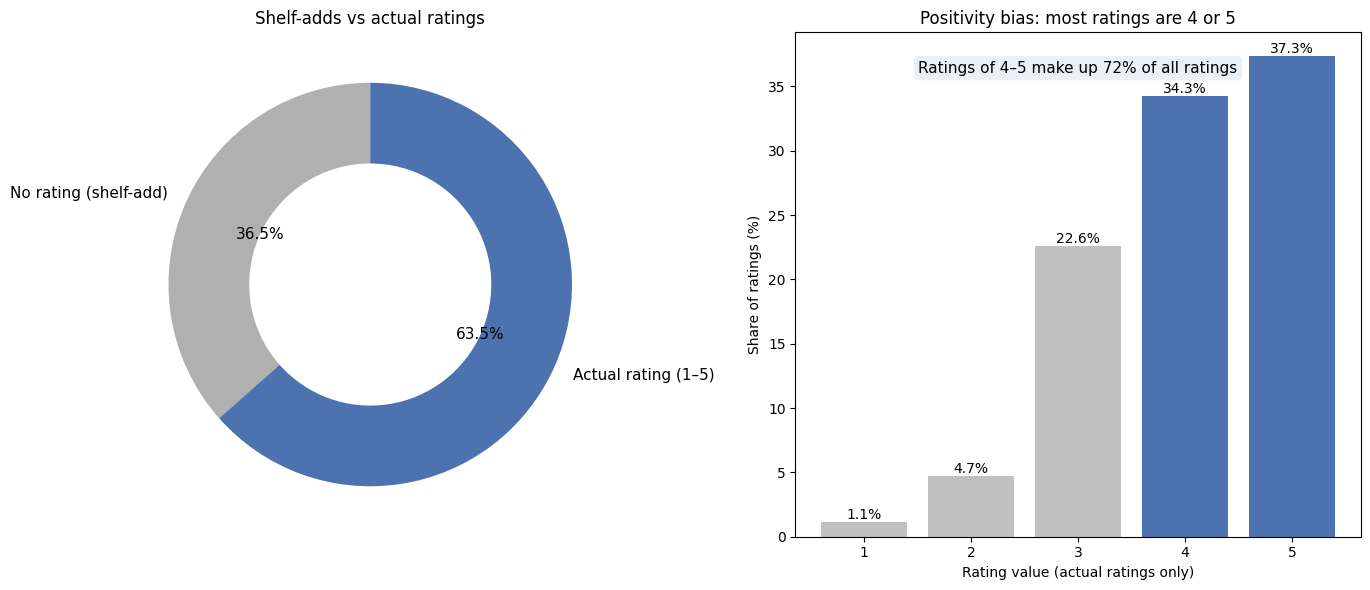

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# === Left: donut — shelf-adds vs actual ratings ===
shelf_adds = rating_counts[0]
actual_ratings = sum(rating_counts[r] for r in range(1, 6))
ax1.pie(
    [shelf_adds, actual_ratings],
    labels=["No rating (shelf-add)", "Actual rating (1–5)"],
    colors=["#B0B0B0", "#4C72B0"],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    wedgeprops=dict(width=0.4),
    textprops={"fontsize": 11},
)
ax1.set_title("Shelf-adds vs actual ratings")

# === Right: positivity bias — actual ratings only (1-5) ===
actual = {r: rating_counts[r] for r in range(1, 6)}
total_actual = sum(actual.values())
ratings = list(actual.keys())
percentages = [actual[r] / total_actual * 100 for r in ratings]
colors = ["#C0C0C0", "#C0C0C0", "#C0C0C0", "#4C72B0", "#4C72B0"]

bars = ax2.bar(ratings, percentages, color=colors)
for bar, pct in zip(bars, percentages):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
ax2.set_xlabel("Rating value (actual ratings only)")
ax2.set_ylabel("Share of ratings (%)")
ax2.set_title("Positivity bias: most ratings are 4 or 5")
ax2.set_xticks(ratings)
high_share = percentages[3] + percentages[4]
ax2.text(0.5, 0.92, f"Ratings of 4–5 make up {high_share:.0f}% of all ratings",
         transform=ax2.transAxes, ha="center", fontsize=11,
         bbox=dict(boxstyle="round", facecolor="#EAF0F8", edgecolor="none"))

plt.tight_layout()
plt.show()

- ~36.5% of interactions are shelf-adds (rating = 0) with no preference signal and will be removed.
- Among actual ratings (1–5), the distribution skews strongly positive: ratings of 4 and 5 dominate. This positivity bias is typical of voluntary rating data and a limitation of our project.

## 3. Sparsity Analysis

In [6]:
# Count ratings per book and per user (actual ratings only)
book_counts = defaultdict(int)
user_counts = defaultdict(int)
total_ratings = 0
with gzip.open(INTERACTIONS_PATH, "rt") as f:
    for line in f:
        rec = json.loads(line)
        if rec["rating"] > 0:
            book_counts[rec["book_id"]] += 1
            user_counts[rec["user_id"]] += 1
            total_ratings += 1

n_books = len(book_counts)
n_users = len(user_counts)
sparsity = 1 - total_ratings / (n_books * n_users)

print(f"Users:   {n_users:,}")
print(f"Books:   {n_books:,}")
print(f"Ratings: {total_ratings:,}")
print(f"Matrix sparsity: {sparsity*100:.4f}%  ({(1-sparsity)*100:.4f}% of cells filled)")

# Long-tail summary
book_vals = np.array(list(book_counts.values()))
user_vals = np.array(list(user_counts.values()))
print(f"\nRatings per book — median: {np.median(book_vals):.0f}, mean: {book_vals.mean():.1f}, max: {book_vals.max():,}")
print(f"Books with < 20 ratings: {(book_vals < 20).mean()*100:.1f}%")
print(f"\nRatings per user — median: {np.median(user_vals):.0f}, mean: {user_vals.mean():.1f}, max: {user_vals.max():,}")
print(f"Users with < 20 ratings: {(user_vals < 20).mean()*100:.1f}%")

Users:   462,164
Books:   122,741
Ratings: 6,384,470
Matrix sparsity: 99.9887%  (0.0113% of cells filled)

Ratings per book — median: 6, mean: 52.0, max: 172,207
Books with < 20 ratings: 77.7%

Ratings per user — median: 3, mean: 13.8, max: 9,882
Users with < 20 ratings: 85.7%


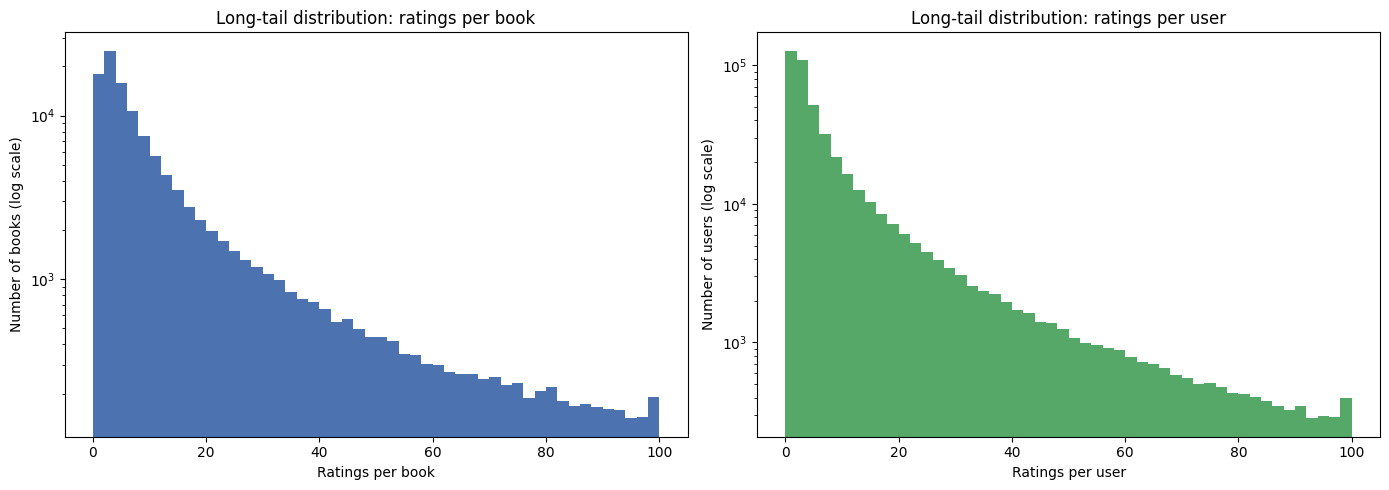

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Ratings per book — log y-axis reveals the long tail; x clipped to show the bulk
ax1.hist(book_vals, bins=range(0, 101, 2), color="#4C72B0")
ax1.set_yscale("log")
ax1.set_xlabel("Ratings per book")
ax1.set_ylabel("Number of books (log scale)")
ax1.set_title("Long-tail distribution: ratings per book")

ax2.hist(user_vals, bins=range(0, 101, 2), color="#55A868")
ax2.set_yscale("log")
ax2.set_xlabel("Ratings per user")
ax2.set_ylabel("Number of users (log scale)")
ax2.set_title("Long-tail distribution: ratings per user")

plt.tight_layout()
plt.show()

- The rating matrix is extremely sparse (99.99% empty), the central challenge of collaborative filtering.
- Both books and users follow a strong long-tail distribution: the median book has only 6 ratings (mean 52, max 172,207) and the median user rated only 3 books (mean 13.8, max 9,882). The large median–mean gap reflects a small head of highly active books/users.
- 77.7% of books and 85.7% of users have fewer than 20 ratings. The 20/20 density filter removes this sparse tail — discarding ~81.3% of books but only ~36.6% of ratings — yielding a denser core better suited to collaborative filtering.

The dataset exhibits a power-law item distribution, where a small number of popular books receive most ratings while many books receive very few ratings. This contributes to data sparsity in the user-item interaction matrix, making it difficult to generate reliable recommendations for less popular books.

## 4. Language Distribution

In [8]:
# Count language_code across all books; track empty/missing explicitly
lang_counts = Counter()
with gzip.open(BOOKS_PATH, "rt") as f:
    for line in f:
        rec = json.loads(line)
        code = (rec.get("language_code") or "").strip()
        lang_counts[code if code else "(empty)"] += 1

total_books = sum(lang_counts.values())
print(f"Total books: {total_books:,}")
print(f"Distinct language codes: {len(lang_counts)}\n")

for code, n in lang_counts.most_common(15):
    print(f"{code:<12} {n:>8,}  ({n/total_books*100:5.1f}%)")

Total books: 124,082
Distinct language codes: 90

(empty)        72,496  ( 58.4%)
eng            30,253  ( 24.4%)
en-US           6,197  (  5.0%)
en-GB           2,071  (  1.7%)
spa             1,501  (  1.2%)
ind             1,147  (  0.9%)
ger             1,043  (  0.8%)
fin               975  (  0.8%)
ita               903  (  0.7%)
nl                837  (  0.7%)
por               821  (  0.7%)
fre               714  (  0.6%)
swe               542  (  0.4%)
per               531  (  0.4%)
ara               438  (  0.4%)


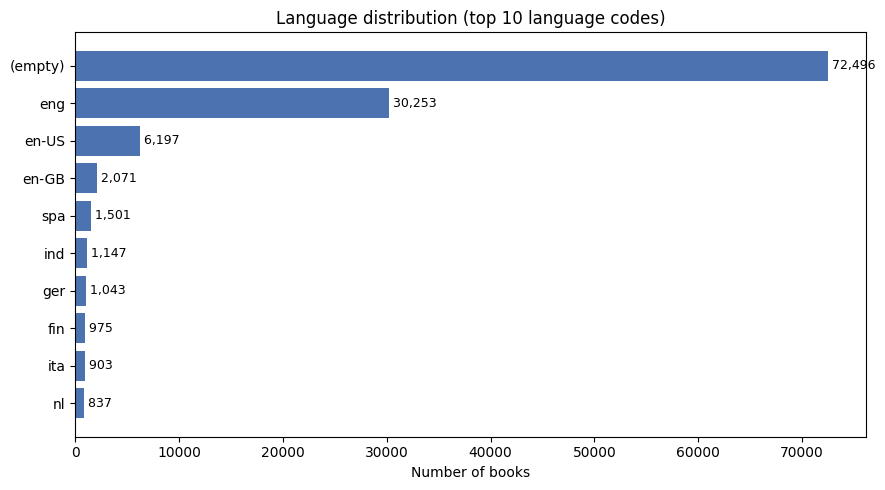

In [9]:
top = lang_counts.most_common(10)
labels = [c for c, _ in top][::-1]      # largest on top
values = [n for _, n in top][::-1]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, values, color="#4C72B0")
for bar, v in zip(bars, values):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f" {v:,}", va="center", fontsize=9)
ax.set_xlabel("Number of books")
ax.set_title("Language distribution (top 10 language codes)")
plt.tight_layout()
plt.show()

- `language_code` is missing for 58.4% of books, making it unreliable as a filter.
- Among coded books, English dominates (eng + en-US + en-GB ≈ 31% of all books); the rest is a thin multilingual tail (~10%) spread across many codes.
- We do not filter by language: the code is too often missing to filter reliably, collaborative filtering operates on rating patterns rather than text, and the density filter (≥20 ratings) should remove most low-rating non-English titles. Any residual non-English content is noted as a minor limitation.

## 5. Genre & Age-Range Characteristics

In [10]:
# Count how many books have each shelf name in their popular_shelves
shelf_counts = Counter()
with gzip.open(BOOKS_PATH, "rt") as f:
    for line in f:
        rec = json.loads(line)
        shelves = rec.get("popular_shelves") or []
        # Use a set so each shelf counts once per book (not once per user)
        shelf_names = {s["name"] for s in shelves if "name" in s}
        shelf_counts.update(shelf_names)

print(f"Distinct shelf names: {len(shelf_counts):,}\n")
print("Top 30 shelves (by number of books):")
for name, n in shelf_counts.most_common(30):
    print(f"  {name:<30} {n:>7,}")

Distinct shelf names: 248,810

Top 30 shelves (by number of books):
  to-read                        122,435
  childrens                       97,408
  children                        91,161
  children-s-books                84,408
  children-s                      83,927
  currently-reading               79,782
  kids                            76,052
  fiction                         75,026
  childrens-books                 67,852
  picture-books                   59,671
  kids-books                      58,893
  favorites                       55,484
  owned                           53,402
  books-i-own                     49,987
  default                         49,549
  library                         47,947
  picture-book                    46,848
  juvenile                        45,057
  children-s-literature           43,306
  childhood                       41,344
  children-s-lit                  38,894
  fantasy                         36,949
  owned-books                 

In [11]:
# Status/organization shelves — not content-relevant
EXCLUDE_SHELVES = {
    "to-read", "currently-reading", "read", "reading",
    "favorites", "owned", "books-i-own", "owned-books",
    "books-i-have", "my-books", "default",
    "library", "my-library", "wish-list", "wishlist",
    "read-aloud", "ebooks", "kindle", "audiobook",
}
content_counts = Counter({k: v for k, v in shelf_counts.items()
                          if k not in EXCLUDE_SHELVES})

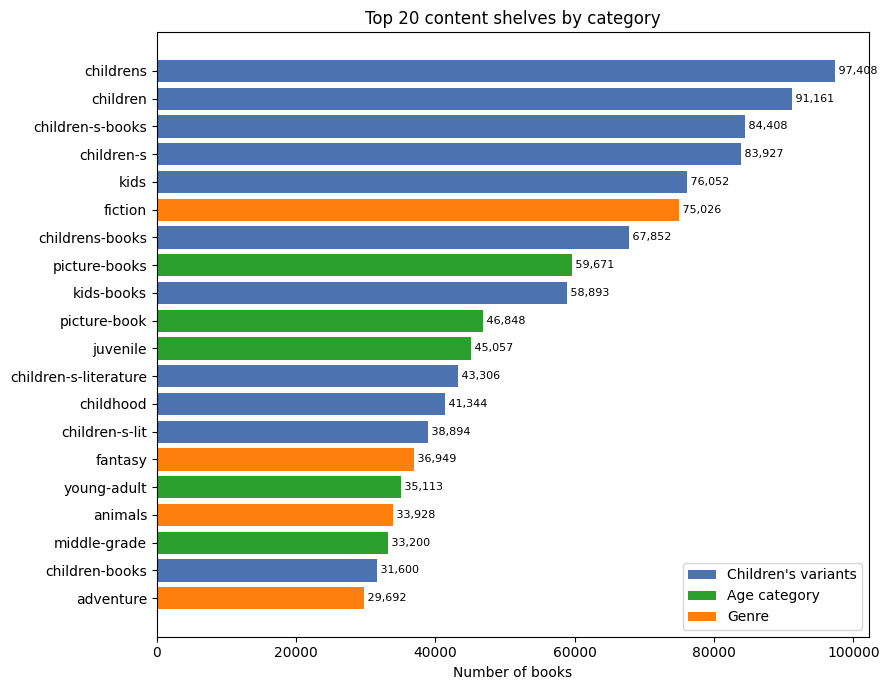

In [12]:
# Assign each shelf to a display category
CATEGORY_MAP = {
    # Children's label variants (same concept, different naming)
    "childrens":             "Children's variants",
    "children":              "Children's variants",
    "children-s-books":      "Children's variants",
    "children-s":            "Children's variants",
    "kids":                  "Children's variants",
    "childrens-books":       "Children's variants",
    "kids-books":            "Children's variants",
    "children-s-literature": "Children's variants",
    "childhood":             "Children's variants",
    "children-s-lit":        "Children's variants",
    "children-books":        "Children's variants",
    # Age-specific shelves
    "picture-books":         "Age category",
    "picture-book":          "Age category",
    "juvenile":              "Age category",
    "middle-grade":          "Age category",
    "young-adult":           "Age category",
    # Genre shelves
    "fiction":               "Genre",
    "fantasy":               "Genre",
    "animals":               "Genre",
    "adventure":             "Genre",
}

COLORS = {
    "Children's variants": "#4C72B0",
    "Age category":        "#2CA02C",
    "Genre":               "#FF7F0E",
}

top_n = content_counts.most_common(20)
labels = [name for name, _ in top_n][::-1]
values = [n for _, n in top_n][::-1]
bar_colors = [COLORS[CATEGORY_MAP.get(l, "Children's variants")] for l in labels]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(labels, values, color=bar_colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f" {v:,}", va="center", fontsize=8)

legend_elements = [Patch(facecolor=c, label=cat) for cat, c in COLORS.items()]
ax.legend(handles=legend_elements, loc="lower right")
ax.set_xlabel("Number of books")
ax.set_title("Top 20 content shelves by category")
plt.tight_layout()
plt.show()

- Age-range tags (picture-books, middle-grade, young-adult/ya, juvenile) appear across tens of thousands of books, confirming that the dataset spans a wide age range rather than targeting a single age group.
- However, popular_shelves is user-generated and voluntary — many books carry no age-related tags at all. With 248,810 distinct shelf names and significant redundancy across variants, the tags are too noisy and incomplete for reliable age classification.
- This means the recommender cannot systematically filter by age appropriateness, which is acknowledged as a limitation in the project's ethical considerations.

# Data Cleaning

**Filter 1 — Remove zero ratings:**  
`rating = 0` indicates a shelf-add with no preference signal; only ratings 1–5 are kept.

**Filter 2 — Book density (≥ 20 ratings):**  
Removes books with fewer than 20 ratings — 77.7% of books fall below this threshold 
and lack sufficient signal for collaborative filtering.

**Filter 3 — User density (≥ 20 ratings):**  
Removes users with fewer than 20 ratings — 85.7% of users fall below this threshold 
and provide too little information for personalized recommendation.

**Threshold selection:**  
A minimum of 20 ratings per book and per user is a standard heuristic in collaborative 
filtering research, consistent with k-core filtering applied to benchmark datasets such 
as MovieLens. The threshold is also empirically justified by our data: as shown in the 
Sparsity Analysis, books and users below this threshold follow an extreme long tail 
(median book has only 6 ratings), and applying this filter retains 63.3% of actual 
ratings while removing 81.3% of books and 86.8% of users — confirming that the 
removed entities contribute relatively little rating signal.

*Filters 2 and 3 are applied iteratively until convergence.*

## 1. Data Loading, Filtering & Creating CSV File

In [13]:
# Load actual ratings (rating > 0), encode user/book IDs as integers
print("Loading interactions (a few minutes)...")
user_to_idx, book_to_idx = {}, {}
user_ids, book_ids = [], []     # original string IDs — needed for saving

raw = []                        # (user_int, book_int, rating)
with gzip.open(INTERACTIONS_PATH, "rt") as f:
    for line in f:
        rec = json.loads(line)
        if rec["rating"] > 0:
            uid, bid = rec["user_id"], rec["book_id"]
            if uid not in user_to_idx:
                user_to_idx[uid] = len(user_ids); user_ids.append(uid)
            if bid not in book_to_idx:
                book_to_idx[bid] = len(book_ids); book_ids.append(bid)
            raw.append((user_to_idx[uid], book_to_idx[bid], rec["rating"]))

arr = np.array(raw, dtype=np.int32)     # shape (N, 3) — compact in memory
del raw
print(f"Loaded:  {len(arr):,} ratings | {len(user_ids):,} users | {len(book_ids):,} books")

Loading interactions (a few minutes)...
Loaded:  6,384,470 ratings | 462,164 users | 122,741 books


In [14]:
MIN = 20
print("Applying 20/20 density filter...")
for i in range(1, 50):
    n_before = len(arr)
    book_counts_iter = np.bincount(arr[:, 1], minlength=len(book_ids))
    user_counts_iter = np.bincount(arr[:, 0], minlength=len(user_ids))
    keep = (book_counts_iter[arr[:, 1]] >= MIN) & (user_counts_iter[arr[:, 0]] >= MIN)
    arr  = arr[keep]
    n_books_iter = np.unique(arr[:, 1]).size
    n_users_iter = np.unique(arr[:, 0]).size
    print(f"  Iteration {i}: {n_before:,} → {len(arr):,} ratings "
          f"| {n_books_iter:,} books | {n_users_iter:,} users")
    if len(arr) == n_before:
        print("  Converged."); break

Applying 20/20 density filter...
  Iteration 1: 6,384,470 → 4,187,804 ratings | 27,403 books | 65,939 users
  Iteration 2: 4,187,804 → 4,086,282 ratings | 23,783 books | 62,566 users
  Iteration 3: 4,086,282 → 4,058,404 ratings | 23,269 books | 61,489 users
  Iteration 4: 4,058,404 → 4,051,262 ratings | 23,059 books | 61,300 users
  Iteration 5: 4,051,262 → 4,048,051 ratings | 23,013 books | 61,172 users
  Iteration 6: 4,048,051 → 4,046,803 ratings | 22,979 books | 61,138 users
  Iteration 7: 4,046,803 → 4,046,058 ratings | 22,960 books | 61,116 users
  Iteration 8: 4,046,058 → 4,045,708 ratings | 22,946 books | 61,111 users
  Iteration 9: 4,045,708 → 4,045,399 ratings | 22,946 books | 61,094 users
  Iteration 10: 4,045,399 → 4,045,206 ratings | 22,935 books | 61,094 users
  Iteration 11: 4,045,206 → 4,044,988 ratings | 22,935 books | 61,082 users
  Iteration 12: 4,044,988 → 4,044,915 ratings | 22,931 books | 61,082 users
  Iteration 13: 4,044,915 → 4,044,839 ratings | 22,931 books | 6

In [15]:
OUTPUT_PATH = "cleaned_ratings.csv"
print(f"Saving to {OUTPUT_PATH}...")

df_clean = pd.DataFrame({
    "user_id": np.array(user_ids, dtype=object)[arr[:, 0]],
    "book_id": np.array(book_ids, dtype=object)[arr[:, 1]],
    "rating":  arr[:, 2],
})
df_clean.to_csv(OUTPUT_PATH, index=False)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"\nSaved: {OUTPUT_PATH}")
print(f"  {len(df_clean):,} ratings | "
      f"{df_clean['book_id'].nunique():,} books | "
      f"{df_clean['user_id'].nunique():,} users | "
      f"{size_mb:.0f} MB")
print(f"\nSample:\n{df_clean.head()}")

Saving to cleaned_ratings.csv...

Saved: cleaned_ratings.csv
  4,044,839 ratings | 22,931 books | 61,078 users | 170 MB

Sample:
                            user_id   book_id  rating
0  8842281e1d1347389f2ab93d60773d4d  23310161       4
1  8842281e1d1347389f2ab93d60773d4d    817720       5
2  8842281e1d1347389f2ab93d60773d4d    502362       5
3  8842281e1d1347389f2ab93d60773d4d   1969280       5
4  8842281e1d1347389f2ab93d60773d4d  17290220       5


**Result:**  
After 3 filters (14 iterations to convergence), the cleaned dataset contains
4,044,839 ratings from 61,078 users across 22,931 books (170 MB).
This retains 63.3% of actual ratings while reducing books to 18.7% and users to 13.2%
of their original counts — discarding the sparse long tail while preserving the dense core.

## 2. Data Validation

In [16]:
# Reload from saved file to validate the actual CSV (not just in-memory state)
df = pd.read_csv("cleaned_ratings.csv")
print(f"{'CHECK':<35} {'RESULT'}")
print("-" * 55)

CHECK                               RESULT
-------------------------------------------------------


In [17]:
# 1. Shape
print(f"{'1. Shape':<35} {df.shape[0]:,} rows × {df.shape[1]} columns")

1. Shape                            4,044,839 rows × 3 columns


In [18]:
# 2. No null values
nulls = df.isnull().sum().sum()
status = "✓ None" if nulls == 0 else f"⚠ {nulls:,} nulls found"
print(f"{'2. Null values':<35} {status}")

2. Null values                      ✓ None


In [19]:
# 3. Rating range (must be 1–5)
r_min, r_max = df["rating"].min(), df["rating"].max()
status = f"✓ [{r_min}, {r_max}]" if r_min >= 1 and r_max <= 5 else f"⚠ Out of range: [{r_min}, {r_max}]"
print(f"{'3. Rating range':<35} {status}")

3. Rating range                     ✓ [1, 5]


In [20]:
# 4. Duplicate (user_id, book_id) pairs
n_dupes = df.duplicated(subset=["user_id", "book_id"]).sum()
status = "✓ None" if n_dupes == 0 else f"⚠ {n_dupes:,} duplicates found"
print(f"{'4. Duplicate user-book pairs':<35} {status}")

4. Duplicate user-book pairs        ✓ None


In [21]:
# 5. Density filter guarantee (every book ≥20, every user ≥20)
book_min = df.groupby("book_id")["rating"].count().min()
user_min = df.groupby("user_id")["rating"].count().min()
b_status = f"✓ min={book_min}" if book_min >= 20 else f"⚠ min={book_min} (below threshold)"
u_status = f"✓ min={user_min}" if user_min >= 20 else f"⚠ min={user_min} (below threshold)"
print(f"{'5a. Min ratings per book':<35} {b_status}")
print(f"{'5b. Min ratings per user':<35} {u_status}")

5a. Min ratings per book            ✓ min=20
5b. Min ratings per user            ✓ min=20


## 3. Fill Rate Analysis

In [22]:
# Fill rate before/after cleaning
# n_users, n_books, total_ratings are computed in Section 3 (Sparsity Analysis)
n_users_clean   = df["user_id"].nunique()
n_books_clean   = df["book_id"].nunique()
n_ratings_clean = len(df)

fill_raw   = total_ratings / (n_users * n_books) * 100
fill_clean = n_ratings_clean / (n_users_clean * n_books_clean) * 100

print(f"{'':25} {'Before cleaning':>16} {'After cleaning':>16}")
print("-" * 58)
print(f"{'Users':25} {n_users:>16,} {n_users_clean:>16,}")
print(f"{'Books':25} {n_books:>16,} {n_books_clean:>16,}")
print(f"{'Ratings':25} {total_ratings:>16,} {n_ratings_clean:>16,}")
print(f"{'Fill rate':25} {fill_raw:>15.4f}% {fill_clean:>15.3f}%")
print(f"{'Density increase':25} {'—':>16} {fill_clean/fill_raw:>15.1f}×")

                           Before cleaning   After cleaning
----------------------------------------------------------
Users                              462,164           61,078
Books                              122,741           22,931
Ratings                          6,384,470        4,044,839
Fill rate                          0.0113%           0.289%
Density increase                         —            25.7×


**Observations:**
- After cleaning, the fill rate increases ~25× (0.0113% → 0.29%), reflecting the removal 
  of the sparse long tail.
- The matrix remains highly sparse (0.29% fill rate), in the same order of magnitude 
  as standard CF benchmarks (e.g., MovieLens 20M: ~0.53%).
- The 20/20 density filter's contribution is not eliminating sparsity, but guaranteeing 
  a minimum of 20 ratings per book and per user — providing sufficient signal for the 
  model to learn meaningful patterns.

## 4. Extract book side features

Parse the raw Goodreads books file and keep structured numeric features for the
22,931 books in our cleaned data. Saved as book_features.csv for the side-feature
TwoTower experiment. (Shelf tags excluded for now — EDA showed them too noisy.)

In [ ]:
# Which books we need
cleaned = pd.read_csv("cleaned_ratings.csv")
needed = set(cleaned["book_id"].astype(str).unique())

NUM_FIELDS = ["average_rating", "ratings_count", "text_reviews_count",
              "num_pages", "publication_year"]
records = []
with gzip.open(BOOKS_PATH, "rt") as f:
    for line in f:
        b = json.loads(line)
        bid = str(b.get("book_id", ""))
        if bid in needed:
            row = {"book_id": bid}
            for fld in NUM_FIELDS:
                v = b.get(fld, "")
                row[fld] = float(v) if v not in ("", None) else float("nan")
            records.append(row)

book_features = pd.DataFrame(records)

# Clean: num_pages==0 -> NaN; publication_year out of range -> NaN; then median fill
book_features.loc[book_features["num_pages"] == 0, "num_pages"] = float("nan")
book_features.loc[(book_features["publication_year"] < 1900) |
                  (book_features["publication_year"] > 2025), "publication_year"] = float("nan")
for col in ["num_pages", "publication_year"]:
    book_features[col] = book_features[col].fillna(book_features[col].median())

book_features.to_csv("book_features.csv", index=False)
print("Re-extracted clean book_features.csv:", book_features.shape)
print(book_features[NUM_FIELDS].describe().loc[["min", "max", "mean"]])

Re-extracted clean book_features.csv: (22931, 6)
      average_rating  ratings_count  text_reviews_count    num_pages  \
min          2.11000   4.400000e+01            1.000000     1.000000   
max          4.75000   1.876252e+06        49850.000000  3520.000000   
mean         3.92034   2.651648e+03          117.697048    98.364136   

      publication_year  
min        1900.000000  
max        2017.000000  
mean       2004.359644  


## 5. Impact of Books with Duplicate Editions

Goodreads distinguishes a *work* from a *book* (a specific edition), so one work can map to
several `book_id`s. Here, 3,701 of 22,931 books (**16.1%**) are alternate editions of 1,241
multi-edition works. We keep editions unmerged, having checked the impact at three levels:

- **Evaluation — negligible.** Editions of one work would only distort a score if they
  co-occurred in a user's candidate pool; with 100 random negatives from ~23k items and only
  2–3 editions per work, this is vanishingly rare.
- **Training — none.** Multi-edition books actually have *more* interactions per edition than
  single-edition ones (median 53 vs. 45), since books are re-issued because they are popular;
  each edition retains ample signal.
- **Display — minor.** Top-K lists can repeat a title within the 16% multi-edition subset; this
  is a presentation artifact, fixed by collapsing on `work_id` at display time.

Merging at the source would require re-cleaning, re-splitting, and retraining both models for
no measurable benefit, so we de-duplicate by work only at display time.

In [32]:
# How many of our 22,931 books are actually duplicate editions of the same work?
cleaned = pd.read_csv("cleaned_ratings.csv")
needed = set(cleaned["book_id"].astype(str).unique())

book_to_work = {}
with gzip.open("../goodreads_books_children.json.gz", "rt") as f:
    for line in f:
        b = json.loads(line)
        bid = str(b.get("book_id", ""))
        if bid in needed:
            book_to_work[bid] = b.get("work_id", "")

work_counts = pd.Series(list(book_to_work.values())).value_counts()
n_books = len(book_to_work)
n_works = work_counts.nunique() if False else len(work_counts)
multi_version_works = (work_counts > 1).sum()
books_in_multi = work_counts[work_counts > 1].sum()

print(f"Total books (editions): {n_books:,}")
print(f"Distinct works:         {n_works:,}")
print(f"Works with >1 edition:  {multi_version_works:,}")
print(f"Books that are part of a multi-edition work: {books_in_multi:,} "
      f"({books_in_multi/n_books*100:.1f}%)")
print(f"\nEdition-count distribution (top):")
print(work_counts.value_counts().sort_index().head(10))

Total books (editions): 22,931
Distinct works:         20,471
Works with >1 edition:  1,241
Books that are part of a multi-edition work: 3,701 (16.1%)

Edition-count distribution (top):
count
1     19230
2       846
3       188
4        68
5        46
6        21
7        22
8         7
9        12
10        6
Name: count, dtype: int64


In [33]:
# book_id -> work_id, and which books are multi-edition
cleaned = pd.read_csv("cleaned_ratings.csv")
needed = set(cleaned["book_id"].astype(str).unique())
book_to_work = {}
with gzip.open("../goodreads_books_children.json.gz", "rt") as f:
    for line in f:
        b = json.loads(line)
        bid = str(b.get("book_id", ""))
        if bid in needed:
            book_to_work[bid] = b.get("work_id", "")

work_counts = pd.Series(list(book_to_work.values())).value_counts()
multi_works = set(work_counts[work_counts > 1].index)
multi_books = {bid for bid, w in book_to_work.items() if w in multi_works}

# Per-book interaction counts in train
book_train_counts = cleaned["book_id"].astype(str).value_counts()

single_counts = [book_train_counts.get(b, 0) for b in book_to_work if b not in multi_books]
multi_counts  = [book_train_counts.get(b, 0) for b in multi_books]

print(f"Single-edition books: {len(single_counts):,}, "
      f"median interactions = {np.median(single_counts):.0f}, mean = {np.mean(single_counts):.0f}")
print(f"Multi-edition books:  {len(multi_counts):,}, "
      f"median interactions = {np.median(multi_counts):.0f}, mean = {np.mean(multi_counts):.0f}")

Single-edition books: 19,230, median interactions = 45, mean = 99
Multi-edition books:  3,701, median interactions = 53, mean = 580


## 6. Data Leakage Audit

We audit the pipeline before trusting the results. The first three checks confirm no leakage; the fourth flags a modeling choice, not a leak.

- **No cross-split overlap** — train∩val, train∩test, val∩test are all 0; no (user, book) pair is tested after being trained on.
- **Clean partition** — split sizes sum to 4,044,839 = the number of unique pairs, so no pair is duplicated across splits.
- **Genuine negatives** — across 2,000 sampled users' candidate pools, 0 negatives are actually train/test items, so NDCG isn't inflated by mislabeled false negatives.
- **Modeling choice (not leakage)** — treating all interactions as positive labels 5.9% (189,579) of 1–2★ "read-but-disliked" interactions as positives; small share, standard implicit-feedback practice, noted as a minor limitation.

Together these confirm the strong NDCG reflects the evaluation design — not data leakage.

In [35]:
# Load raw splits fresh — independent of any kernel state
train = pd.read_csv("train_ratings.csv")
val   = pd.read_csv("val_ratings.csv")
test  = pd.read_csv("test_ratings.csv")

print("=== CHECK 1: No (user, book) pair appears in more than one split ===")
def pair_set(df):
    return set(zip(df["user_id"], df["book_id"]))
tr, va, te = pair_set(train), pair_set(val), pair_set(test)
print(f"  train∩val  overlap: {len(tr & va)}")
print(f"  train∩test overlap: {len(tr & te)}")
print(f"  val∩test   overlap: {len(va & te)}")
print(f"  → all should be 0")

print("\n=== CHECK 2: Split sizes & disjointness ===")
total = len(tr) + len(va) + len(te)
all_pairs = tr | va | te
print(f"  sum of splits: {total:,} | unique pairs: {len(all_pairs):,}")
print(f"  → equal means no duplicate pairs across splits: {total == len(all_pairs)}")

print("\n=== CHECK 3: Candidate-pool negatives exclude train+test items ===")
# Rebuild the exclusion logic and verify negatives are truly unseen
train_items_by_user = train.groupby("user_id")["book_id"].apply(set).to_dict()
test_items_by_user  = test.groupby("user_id")["book_id"].apply(set).to_dict()

rng = np.random.default_rng(42)
all_items_arr = np.asarray(train["book_id"].unique())
leak_count = 0
checked = 0
for user in list(test_items_by_user.keys())[:2000]:   # sample 2000 users
    seen = train_items_by_user.get(user, set())
    pos  = test_items_by_user[user]
    exclude = seen | pos
    # sample negatives exactly as build_candidate_pools does
    negs = []
    while len(negs) < 100:
        cand = rng.choice(all_items_arr, size=200, replace=False)
        negs = [it for it in cand if it not in exclude][:100]
    # verify: no negative is in the user's train or test items
    leaked = [it for it in negs if it in exclude]
    leak_count += len(leaked)
    checked += 1
print(f"  checked {checked} users, leaked negatives found: {leak_count}")
print(f"  → should be 0 (negatives never overlap train/test items)")

print("\n=== CHECK 4: Are low-rating interactions (1-2 stars) treated as positives? ===")
# This isn't leakage, but a modeling choice worth being aware of
rating_dist = train["rating"].value_counts().sort_index()
print(rating_dist)
low = train[train["rating"] <= 2].shape[0]
print(f"  ratings ≤2 stars treated as label=1 positives: {low:,} ({low/len(train)*100:.1f}%)")

=== CHECK 1: No (user, book) pair appears in more than one split ===
  train∩val  overlap: 0
  train∩test overlap: 0
  val∩test   overlap: 0
  → all should be 0

=== CHECK 2: Split sizes & disjointness ===
  sum of splits: 4,044,839 | unique pairs: 4,044,839
  → equal means no duplicate pairs across splits: True

=== CHECK 3: Candidate-pool negatives exclude train+test items ===
  checked 2000 users, leaked negatives found: 0
  → should be 0 (negatives never overlap train/test items)

=== CHECK 4: Are low-rating interactions (1-2 stars) treated as positives? ===
rating
1      33676
2     155903
3     771533
4    1129607
5    1145154
Name: count, dtype: int64
  ratings ≤2 stars treated as label=1 positives: 189,579 (5.9%)
